In [32]:
import pandas as pd
url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch06/BostonHousing.csv'
df = pd.read_csv(url)
df = df[['CRIM', 'LSTAT', 'AGE', 'MEDV']]
print(df.head( ))



      CRIM  LSTAT   AGE  MEDV
0  0.00632   4.98  65.2  24.0
1  0.02731   9.14  78.9  21.6
2  0.02729   4.03  61.1  34.7
3  0.03237   2.94  45.8  33.4
4  0.06905   5.33  54.2  36.2


/tmp/ipykernel_2848/2034136386.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax=axes[i], kde=True, hist=False, color='blue')
/tmp/ipykernel_2848/2034136386.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax=axes[i], kde=True, hist=False, color='blu

IndexError: index 3 is out of bounds for axis 0 with size 3

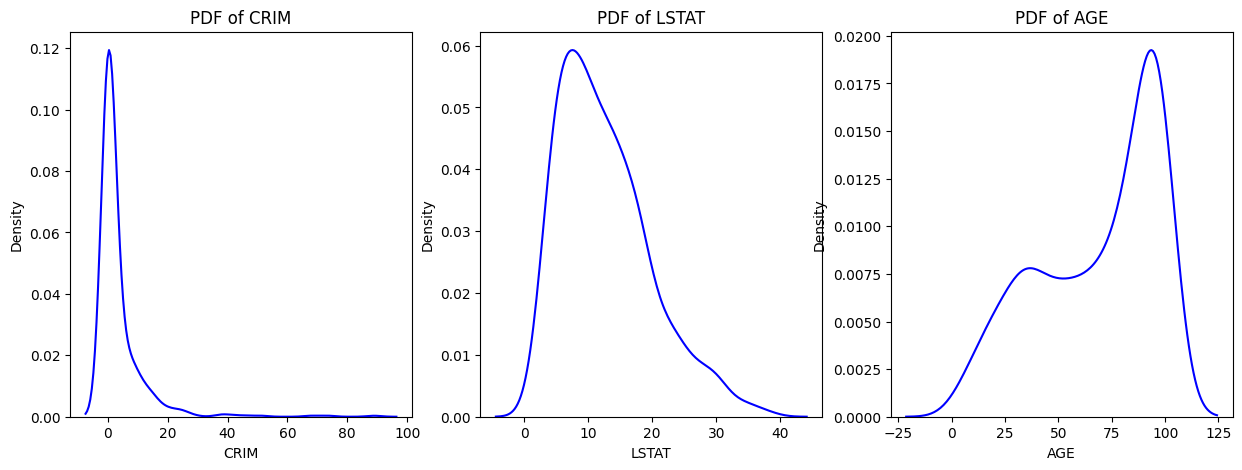

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot PDFs using distplot and calculate skewness
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

skew_values = {}

for i, col in enumerate(df.columns):
    sns.distplot(df[col], ax=axes[i], kde=True, hist=False, color='blue')
    axes[i].set_title(f"PDF of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    skew_values[col] = df[col].skew()

plt.tight_layout()
plt.show()

In [21]:
print("Skewness of CRIM column", df['CRIM'].skew())
print("Skewness of LSTAT column", df['LSTAT'].skew())
print("Skewness of AGE column", df['AGE'].skew())

Skewness of CRIM column 5.223148798243851
Skewness of LSTAT column 0.9064600935915367
Skewness of AGE column -0.5989626398812962


In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 0:3], df.iloc[:, 3], test_size=0.2, random_state=42)
print(X_train.head())

         CRIM  LSTAT   AGE
477  15.02340  24.91  97.3
15    0.62739   8.47  56.5
332   0.03466   7.83  23.3
423   7.05042  23.29  85.1
19    0.72580  11.28  69.5


In [38]:
# Applying the specified transformations
X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()

In [39]:
import numpy as np

X_train_transformed["CRIM"] = np.log1p(X_train["CRIM"])
X_train_transformed["LSTAT"] = np.sqrt(X_train["LSTAT"])
X_train_transformed["AGE"] = np.square(X_train["AGE"])
X_test_transformed["CRIM"] = np.log1p(X_test["CRIM"])
X_test_transformed["LSTAT"] = np.sqrt(X_test["LSTAT"])
X_test_transformed["AGE"] = np.square(X_test["AGE"])

In [45]:
print("Skewness of CRIM column", X_train['CRIM'].skew())
print("Skewness of LSTAT column", X_train['LSTAT'].skew())
print("Skewness of AGE column", X_train['AGE'].skew())

Skewness of CRIM column 5.4652724790291005
Skewness of LSTAT column 0.9337198316549744
Skewness of AGE column -0.618827159904554


In [47]:
print("Skewness of CRIM column after log transformation -> ", X_train_transformed['CRIM'].skew())
print("Skewness of LSTAT column after square root transformation -> ", X_train_transformed['LSTAT'].skew())
print("Skewness of AGE column after square transformation -> ", X_train_transformed['AGE'].skew())

Skewness of CRIM column after log transformation ->  1.3059612838302206
Skewness of LSTAT column after square root transformation ->  0.3426276466135188
Skewness of AGE column after square transformation ->  -0.18890793399789416


/tmp/ipykernel_2848/235540241.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax=axes[i, 0], kde=True, hist=False, color='blue')
/tmp/ipykernel_2848/235540241.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col], ax=axes[i, 1], kde=True, hi

IndexError: index 3 is out of bounds for axis 0 with size 3

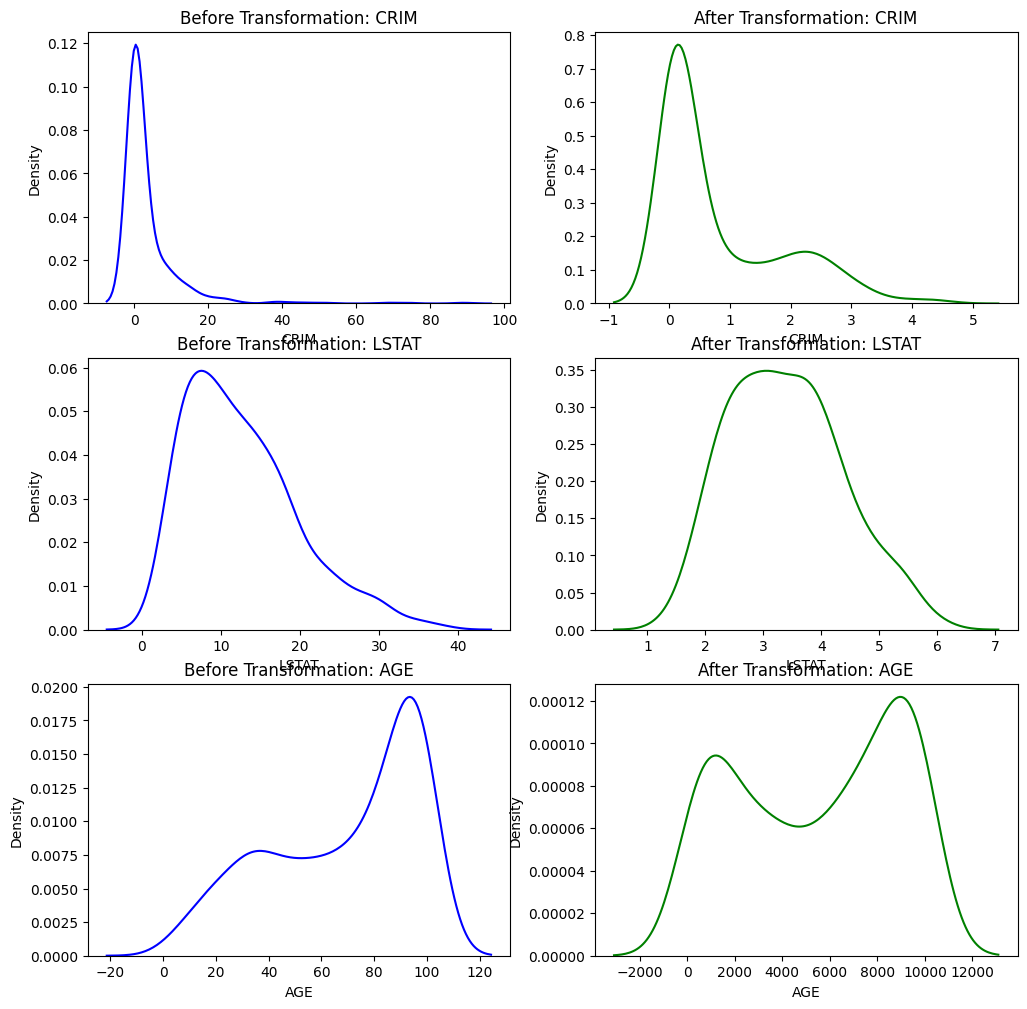

In [48]:
# Setting up a grid for before and after PDF plots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Plotting before and after PDFs for each feature
for i, col in enumerate(df.columns):
    # Before transformation
    sns.distplot(df[col], ax=axes[i, 0], kde=True, hist=False, color='blue')
    axes[i, 0].set_title(f"Before Transformation: {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Density")

    # After transformation
    sns.distplot(X_train_transformed[col], ax=axes[i, 1], kde=True, hist=False, color='green')
    axes[i, 1].set_title(f"After Transformation: {col}")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Density")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# apply Linear Regression on transformed data
lr1 = LinearRegression( )
lr1.fit(X_train, y_train)

# predict on the test set
y_pred = lr1.predict(X_test)

# calculate R2 score and mean squared error for transformed data
r2_score_val = r2_score(y_test, y_pred)
mse_val = mean_squared_error(y_test, y_pred)

print("R2_score (greater the better):", r2_score_val)
print("Mean Squared Error (lesser the better):", mse_val)

R2_score (greater the better): 0.5176659709875675
Mean Squared Error (lesser the better): 35.371379094442645


In [51]:
# apply Linear Regression on transformed data
lr2 = LinearRegression()
lr2.fit(X_train_transformed, y_train)

# predict on the test set
y_pred = lr2.predict(X_test_transformed)

# calculate R2 Score and Mean Squared Error for transformed data
r2_score_val = r2_score(y_test, y_pred)
mse_val = mean_squared_error(y_test, y_pred)

print("R2_score (greater the better):", r2_score_val)
print("Mean Squared Error (lesser the better):", mse_val)


R2_score (greater the better): 0.6175852163048823
Mean Squared Error (lesser the better): 28.043922824799573


In [52]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

print(pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_}))

    cols  box_cox_lambdas
0   CRIM        -0.114374
1  LSTAT         0.203126
2    AGE         1.362922
